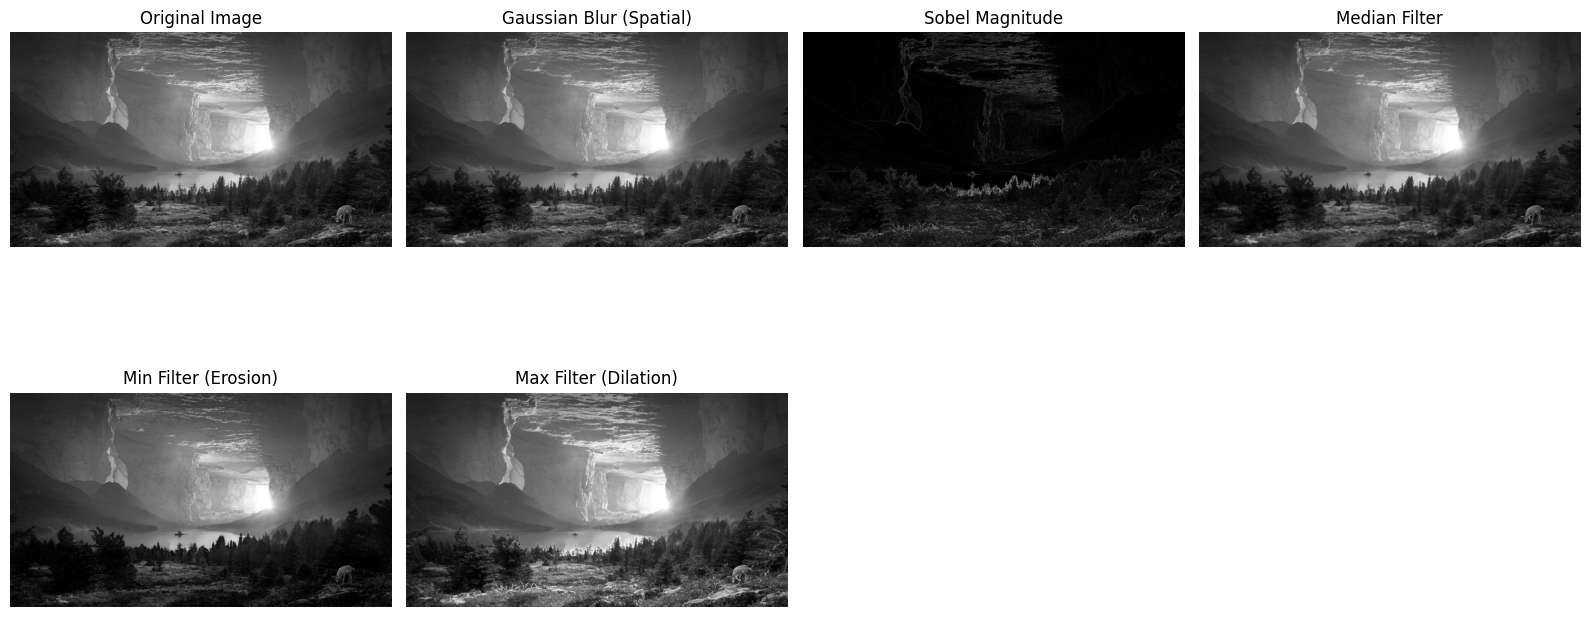

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('E:\Computer Vision\LAB\lab02\q2.jpg', cv2.IMREAD_GRAYSCALE)

gaussian_kernel = np.array([[1, 2, 1],
                            [2, 4, 2],
                            [1, 2, 1]]) / 16.0
spatial_gaussian = cv2.filter2D(image, -1, gaussian_kernel)

sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitude = np.uint8(255 * sobel_magnitude / np.max(sobel_magnitude))

median_filt = cv2.medianBlur(image, 5) 
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)) 
min_filt = cv2.erode(image, kernel) 
max_filt = cv2.dilate(image, kernel) 

plt.figure(figsize=(16, 8))

plt.subplot(2, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(spatial_gaussian, cmap='gray')
plt.title('Gaussian Blur (Spatial)')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(median_filt, cmap='gray')
plt.title('Median Filter')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(min_filt, cmap='gray')
plt.title('Min Filter (Erosion)')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(max_filt, cmap='gray')
plt.title('Max Filter (Dilation)')
plt.axis('off')

plt.tight_layout()
plt.show()

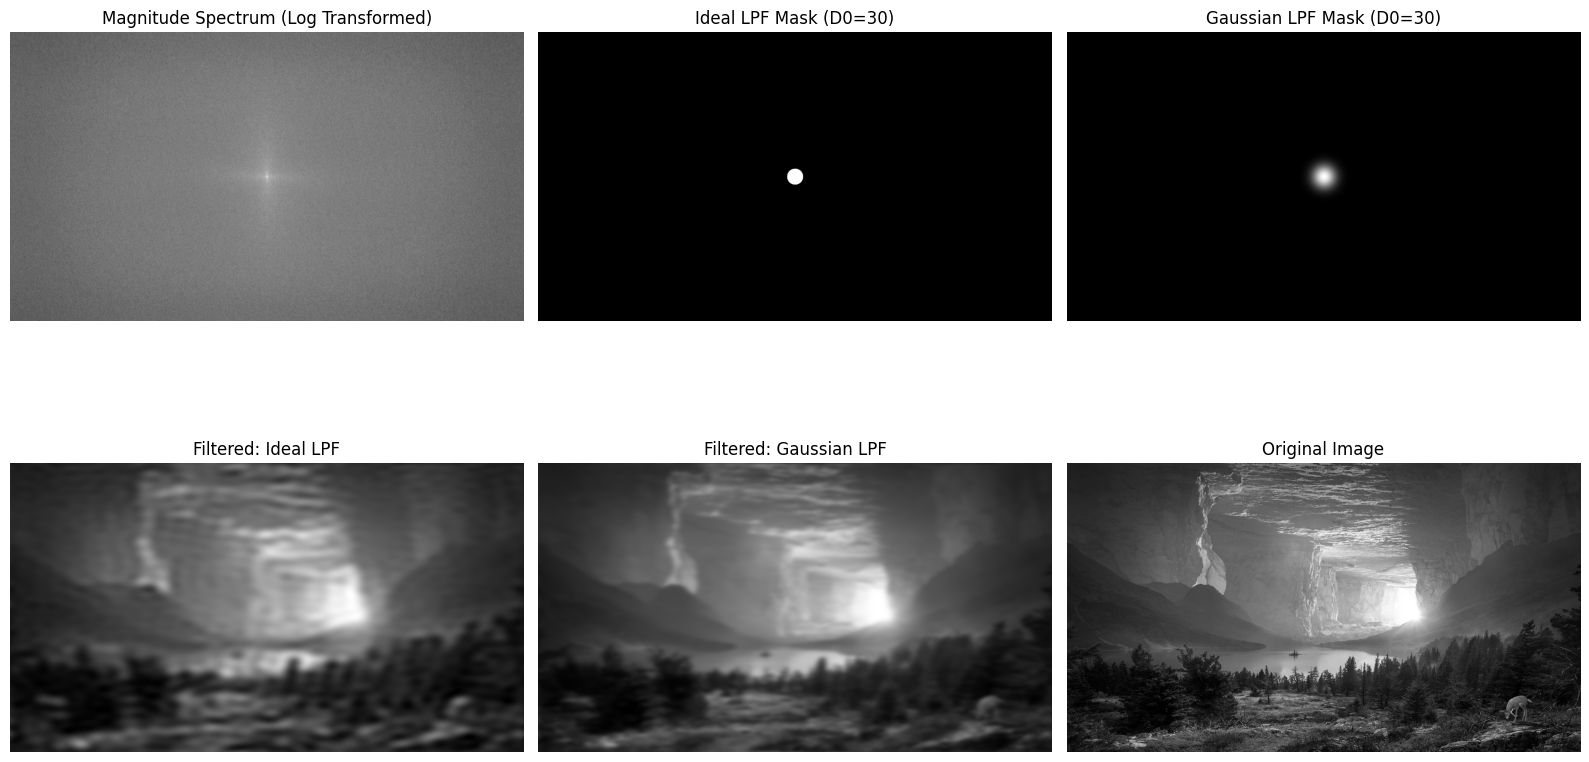

In [7]:
dft = np.fft.fft2(image) 
dft_shift = np.fft.fftshift(dft)  
magnitude_spectrum = 20 * np.log(np.abs(dft_shift))

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2
u, v = np.meshgrid(np.arange(rows), np.arange(cols), indexing='ij')
D = np.sqrt((u - crow)**2 + (v - ccol)**2)

D0 = 30 
H_ideal = np.where(D <= D0, 1, 0) 

n = 2  
H_butter = 1 / (1 + (D / D0)**(2 * n)) 

H_gauss = np.exp(-(D**2) / (2 * (D0**2))) 

def apply_filter(shift_dft, filter_mask):
    filtered_shift = shift_dft * filter_mask
    f_ishift = np.fft.ifftshift(filtered_shift) 
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

ideal_result = apply_filter(dft_shift, H_ideal)
gauss_result = apply_filter(dft_shift, H_gauss)

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum (Log Transformed)')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(H_ideal, cmap='gray')
plt.title(f'Ideal LPF Mask (D0={D0})')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(H_gauss, cmap='gray')
plt.title(f'Gaussian LPF Mask (D0={D0})')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(ideal_result, cmap='gray')
plt.title('Filtered: Ideal LPF')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(gauss_result, cmap='gray')
plt.title('Filtered: Gaussian LPF')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()

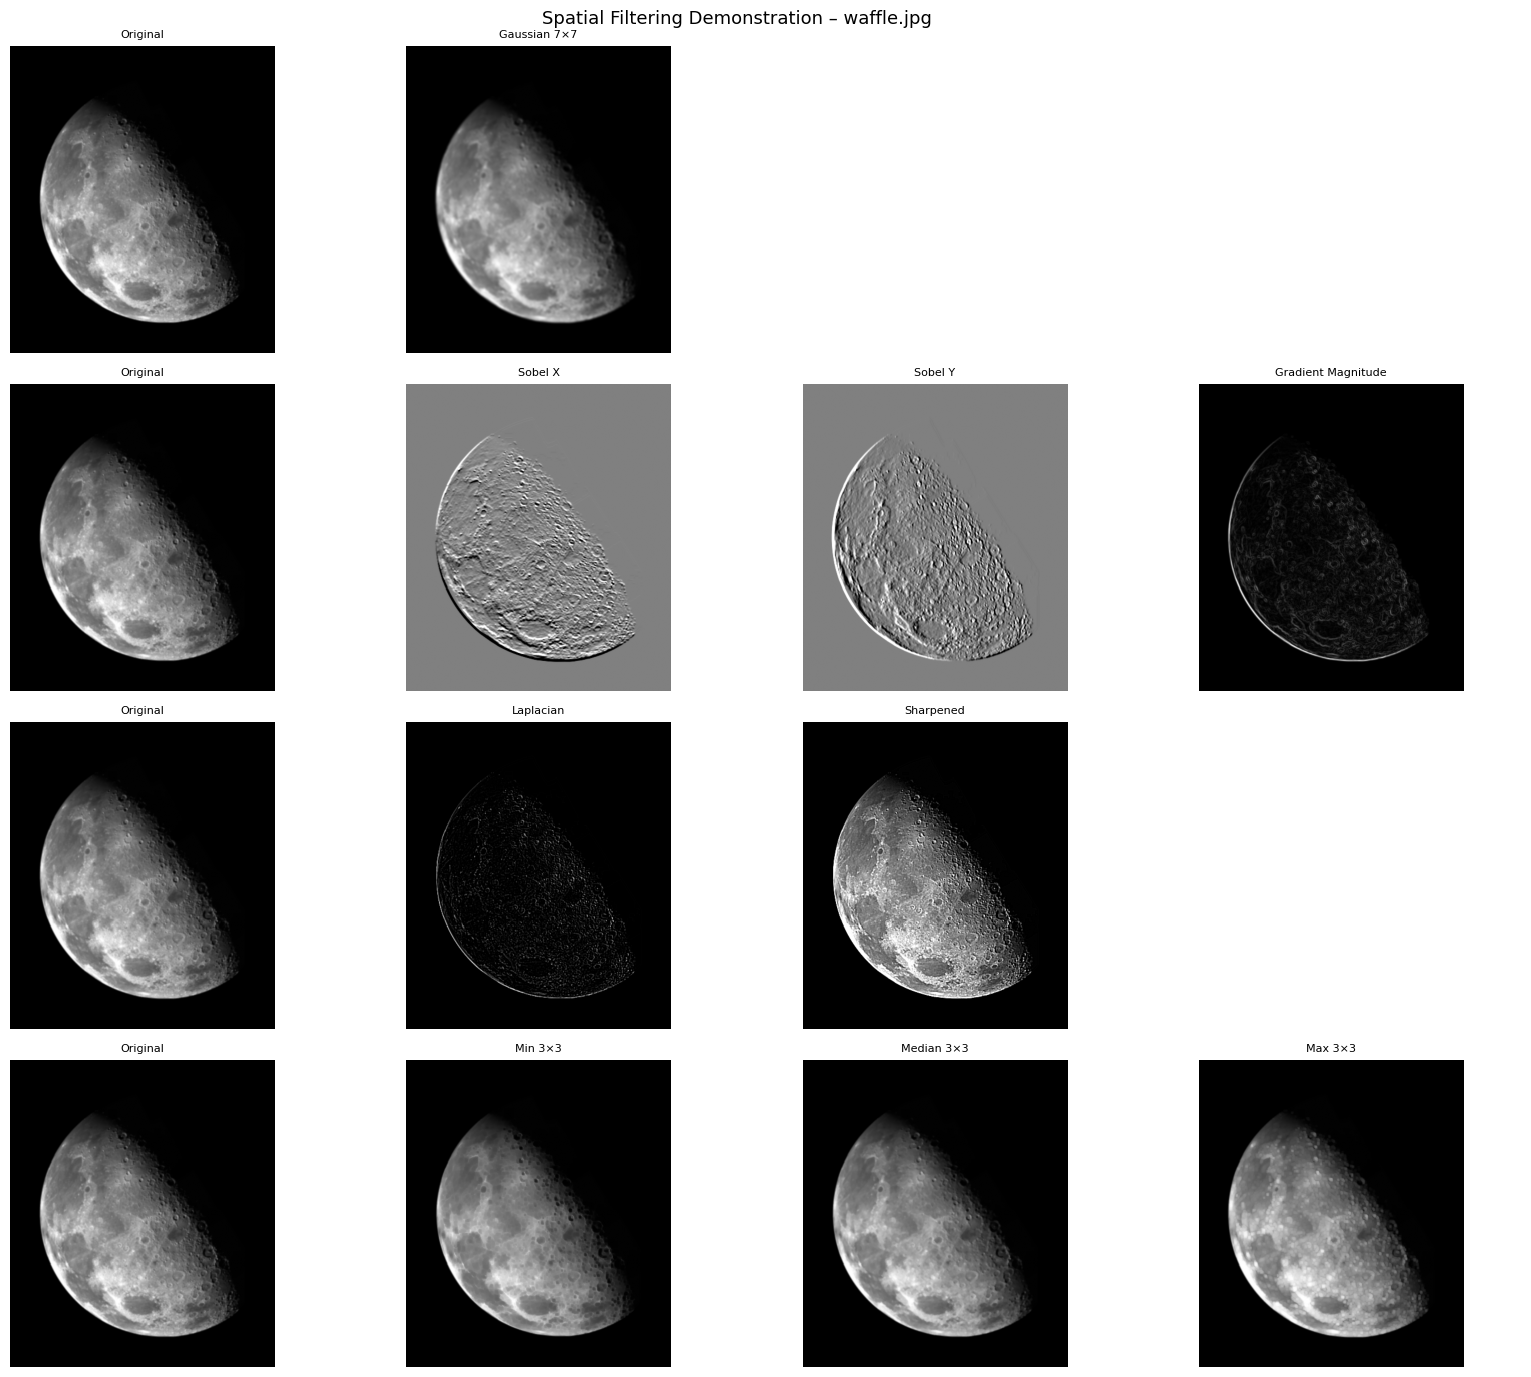

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_path = "E:\Computer Vision\LAB\lab04\Fig03.tif"
gray_image = np.array(Image.open(image_path).convert("L"), dtype=np.float64)

crop_size = 128
center_y, center_x = gray_image.shape[0] // 2, gray_image.shape[1] // 2
half = crop_size // 2

cropped_img = gray_image.copy()




SOBEL_HORIZONTAL = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

SOBEL_VERTICAL = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

LAPLACIAN_KERNEL = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])



def zero_pad(image, pad):
    return np.pad(image, pad_width=pad, mode='constant', constant_values=0)


def apply_kernel(window, kernel):
    return np.sum(window * kernel)


def sliding_window_process(image, kernel=None, operation="convolution"):
    k = kernel.shape[0]
    pad = k // 2
    padded = zero_pad(image, pad)
    result = np.zeros_like(image, dtype=np.float64)

    for r in range(pad, padded.shape[0] - pad):
        for c in range(pad, padded.shape[1] - pad):

            region = padded[r-pad:r+pad+1, c-pad:c+pad+1]

            if operation == "convolution":
                value = apply_kernel(region, kernel)

            elif operation == "min":
                value = np.min(region)

            elif operation == "median":
                value = np.median(region)

            elif operation == "max":
                value = np.max(region)

            else:
                raise ValueError("Unsupported operation type")

            result[r-pad, c-pad] = value

    return result


# GAUSSIAN FILTER

def generate_gaussian(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / kernel.sum()


def gaussian_blur(image, size=7, sigma=1.5):
    g_kernel = generate_gaussian(size, sigma)
    return sliding_window_process(image, g_kernel, "convolution")


# SOBEL EDGE DETECTION

def sobel_edges(image):
    gx = sliding_window_process(image, SOBEL_HORIZONTAL, "convolution")
    gy = sliding_window_process(image, SOBEL_VERTICAL, "convolution")

    magnitude = np.sqrt(gx**2 + gy**2)
    magnitude = (magnitude / magnitude.max()) * 255

    return gx, gy, magnitude.astype(np.uint8)


# LAPLACIAN SHARPENING

def laplacian_enhancement(image):
    lap = sliding_window_process(image, LAPLACIAN_KERNEL, "convolution")
    sharpened = np.clip(image + lap, 0, 255)
    return lap, sharpened


# RANK FILTERS

def rank_operations(image):
    minimum = sliding_window_process(image, np.ones((3,3)), "min")
    median  = sliding_window_process(image, np.ones((3,3)), "median")
    maximum = sliding_window_process(image, np.ones((3,3)), "max")
    return minimum, median, maximum


# NOISE + ERROR METRIC

def salt_pepper_noise(image, ratio=0.08):
    noisy = image.copy()
    total = int(image.size * ratio / 2)

    coords1 = (np.random.randint(0, image.shape[0], total),
               np.random.randint(0, image.shape[1], total))
    coords2 = (np.random.randint(0, image.shape[0], total),
               np.random.randint(0, image.shape[1], total))

    noisy[coords1] = 255
    noisy[coords2] = 0
    return noisy


def compute_mse(img1, img2):
    return np.mean((img1.astype(np.float64) - img2.astype(np.float64))**2)


# EXECUTION PIPELINE

original = cropped_img.copy()
gaussian_output = gaussian_blur(original)
# Sobel gradients
grad_x, grad_y, grad_mag = sobel_edges(original)
# Laplacian sharpening
lap_result, sharpened_img = laplacian_enhancement(original)
lap_display = np.clip(lap_result, 0, 255).astype(np.uint8)
# Rank filtering
min_img, med_img, max_img = rank_operations(original)


# VISUALIZATION

def render_subplot(ax, img, title):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=8)
    ax.axis("off")


fig, ax = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle("Spatial Filtering Demonstration – waffle.jpg", fontsize=13)

render_subplot(ax[0,0], original, "Original")
render_subplot(ax[0,1], gaussian_output, "Gaussian 7×7")
ax[0,2].axis('off')
ax[0,3].axis('off')

render_subplot(ax[1,0], original, "Original")
render_subplot(ax[1,1], np.clip(grad_x+128,0,255), "Sobel X")
render_subplot(ax[1,2], np.clip(grad_y+128,0,255), "Sobel Y")
render_subplot(ax[1,3], grad_mag, "Gradient Magnitude")

render_subplot(ax[2,0], original, "Original")
render_subplot(ax[2,1], lap_display, "Laplacian")
render_subplot(ax[2,2], sharpened_img, "Sharpened")
ax[2,3].axis('off')

render_subplot(ax[3,0], original, "Original")
render_subplot(ax[3,1], min_img, "Min 3×3")
render_subplot(ax[3,2], med_img, "Median 3×3")
render_subplot(ax[3,3], max_img, "Max 3×3")

plt.tight_layout()
plt.savefig("refactored_spatial_filters.png", dpi=130)
plt.show()

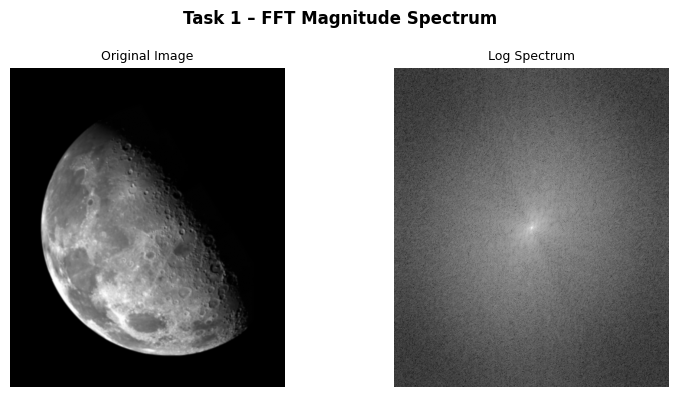

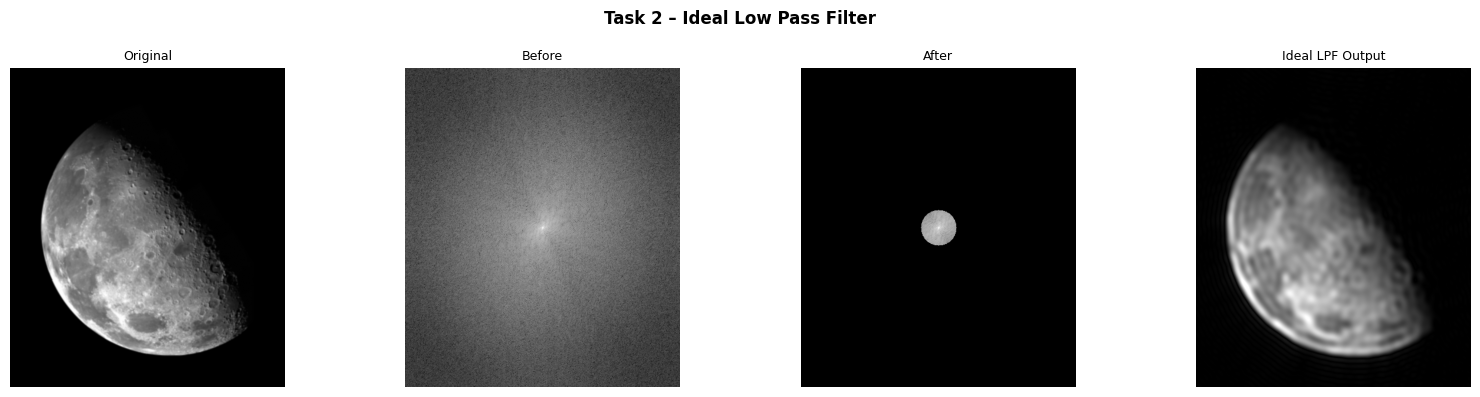

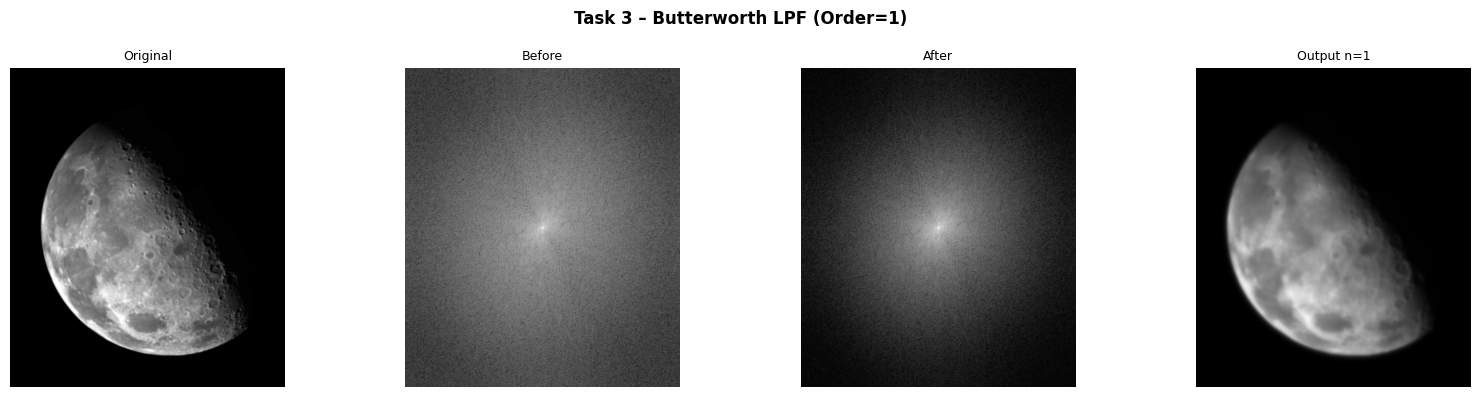

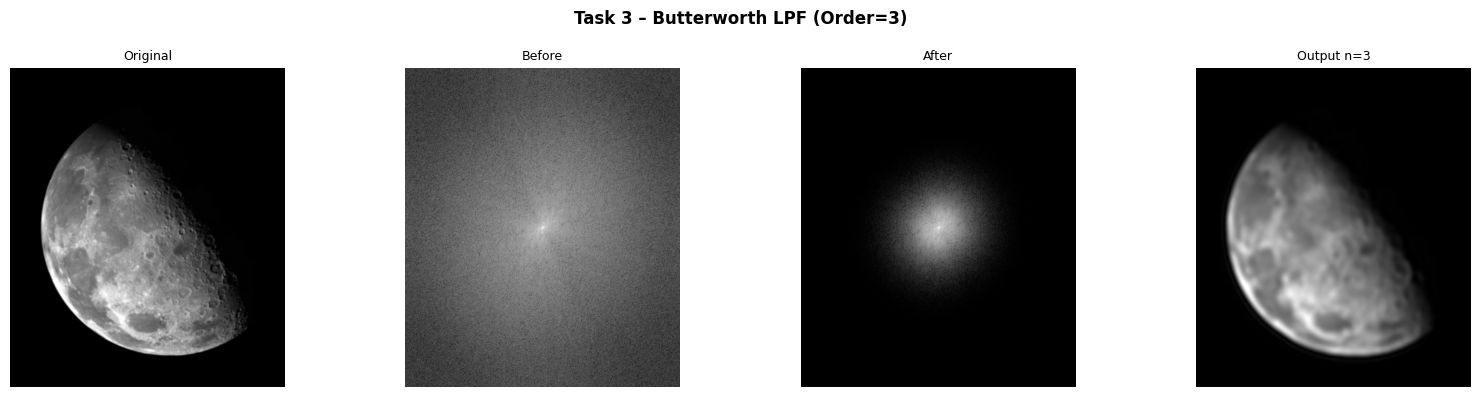

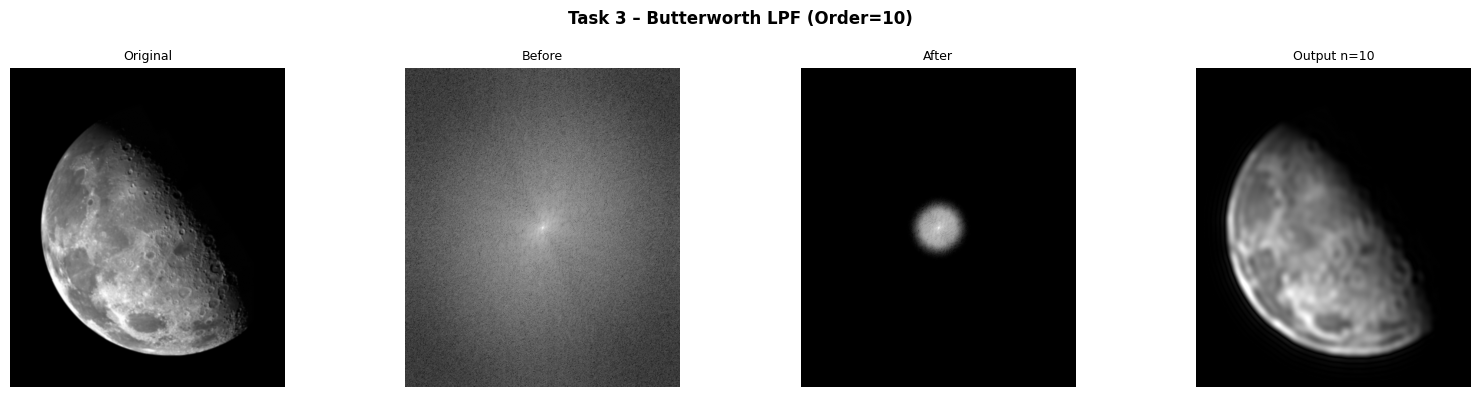

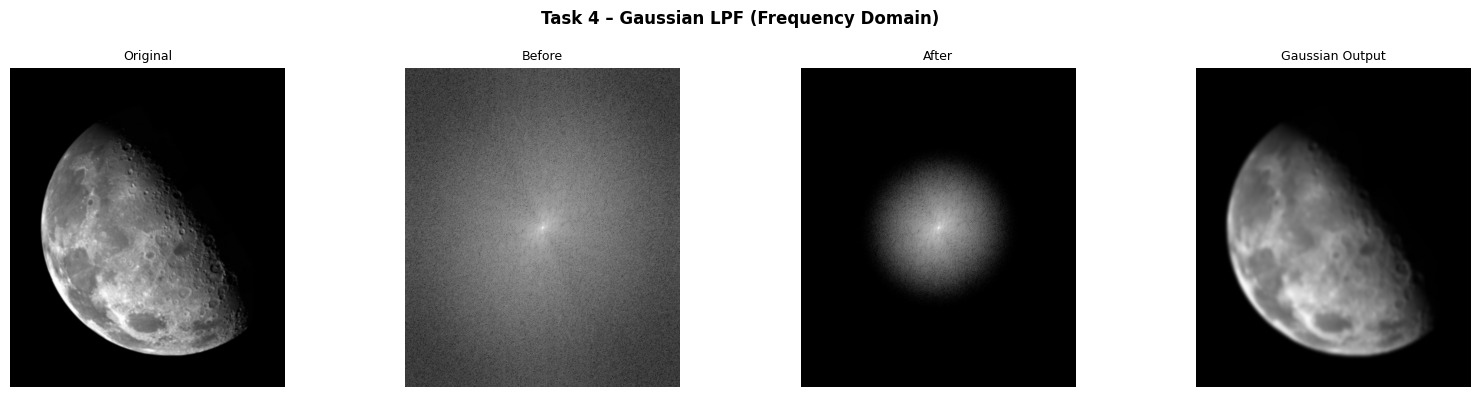

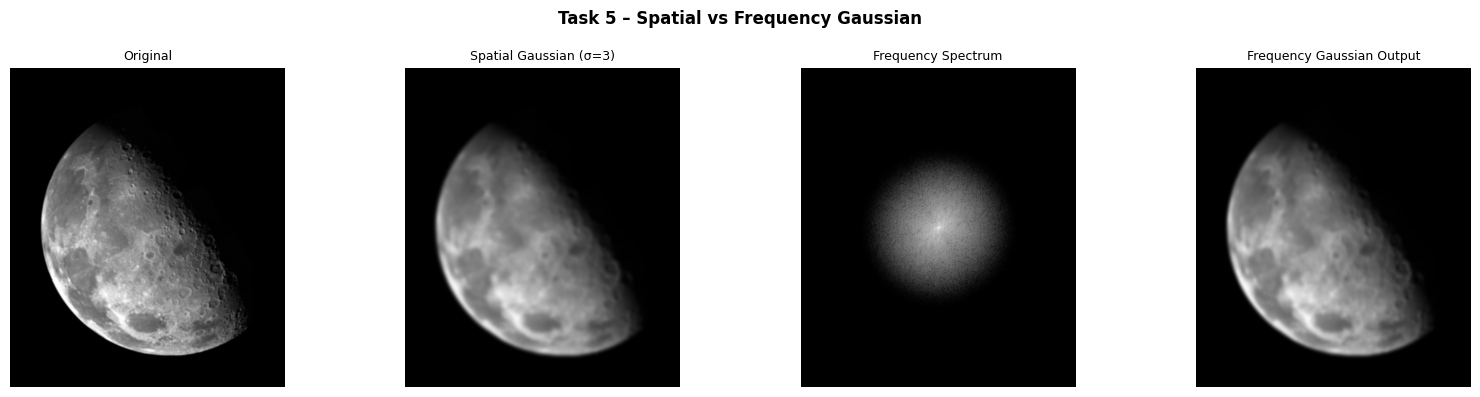

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter as spatial_gaussian
from scipy.fft import fft2, ifft2, fftshift, ifftshift


path = r"E:\Computer Vision\LAB\lab04\Fig03.tif"
image = np.array(Image.open(path).convert("L"), dtype=np.float64)

rows, cols = image.shape

def to_uint8(arr):
    return np.clip(arr, 0, 255).astype(np.uint8)


def spectrum_visual(F_shift):
    mag = np.log1p(np.abs(F_shift))
    mag = mag / mag.max()
    return to_uint8(mag * 255)


def show_img(ax, data, title):
    ax.imshow(data, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')


def show_freq(ax, freq_data, title):
    ax.imshow(spectrum_visual(freq_data), cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')



F = fft2(image)
F_shifted = fftshift(F)

y, x = np.ogrid[:rows, :cols]
D = np.sqrt((y - rows//2)**2 + (x - cols//2)**2)


def ideal_lpf(cutoff):
    return (D <= cutoff).astype(np.float64)


def butterworth_lpf(cutoff, order):
    return 1 / (1 + (D / cutoff) ** (2 * order))


def gaussian_lpf(cutoff):
    return np.exp(-(D**2) / (2 * cutoff**2))


def apply_filter(mask):
    filtered = F_shifted * mask
    reconstructed = ifft2(ifftshift(filtered))
    return to_uint8(np.abs(reconstructed)), filtered



fig, ax = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Task 1 – FFT Magnitude Spectrum", fontweight='bold')

show_img(ax[0], image, "Original Image")
show_freq(ax[1], F_shifted, "Log Spectrum")

plt.tight_layout()
plt.show()


# TASK 2 – IDEAL LOW PASS

mask_ideal = ideal_lpf(30)
ideal_img, ideal_freq = apply_filter(mask_ideal)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Task 2 – Ideal Low Pass Filter", fontweight='bold')

show_img(ax[0], image, "Original")
show_freq(ax[1], F_shifted, "Before")
show_freq(ax[2], ideal_freq, "After")
show_img(ax[3], ideal_img, "Ideal LPF Output")

plt.tight_layout()
plt.show()


# TASK 3 – BUTTERWORTH LOW PASS

for n in [1, 3, 10]:
    mask_bw = butterworth_lpf(30, n)
    bw_img, bw_freq = apply_filter(mask_bw)

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Task 3 – Butterworth LPF (Order={n})", fontweight='bold')

    show_img(ax[0], image, "Original")
    show_freq(ax[1], F_shifted, "Before")
    show_freq(ax[2], bw_freq, "After")
    show_img(ax[3], bw_img, f"Output n={n}")

    plt.tight_layout()
    plt.show()


# TASK 4 – GAUSSIAN LOW PASS (FREQUENCY DOMAIN)

mask_gauss = gaussian_lpf(30)
gauss_img, gauss_freq = apply_filter(mask_gauss)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Task 4 – Gaussian LPF (Frequency Domain)", fontweight='bold')

show_img(ax[0], image, "Original")
show_freq(ax[1], F_shifted, "Before")
show_freq(ax[2], gauss_freq, "After")
show_img(ax[3], gauss_img, "Gaussian Output")

plt.tight_layout()
plt.show()


# TASK 5 – SPATIAL VS FREQUENCY GAUSSIAN

spatial_blur = to_uint8(spatial_gaussian(image, sigma=3))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Task 5 – Spatial vs Frequency Gaussian", fontweight='bold')

show_img(ax[0], image, "Original")
show_img(ax[1], spatial_blur, "Spatial Gaussian (σ=3)")
show_freq(ax[2], gauss_freq, "Frequency Spectrum")
show_img(ax[3], gauss_img, "Frequency Gaussian Output")

plt.tight_layout()
plt.show()